## Análise inicial - Projeto do Ciclo Básico InsperData - Grupo 2
#### Integrantes:  Laura, Matias e Vinícius

Importação das bibliotecas necessárias:

In [2]:
from nba_api.stats.endpoints import leaguegamelog
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Pegando os dados da última temporada
gamelog = leaguegamelog.LeagueGameLog(season="2024-25", season_type_all_star="Regular Season")
dataframe = gamelog.get_data_frames()[0] #lista com 1 df com os filtros selecionados, pegar esse único termo

dataframe.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22024,1610612738,BOS,Boston Celtics,0022400061,2024-10-22,BOS vs. NYK,W,240,48,...,29,40,33,6,3,4,15,132,23,1
1,22024,1610612750,MIN,Minnesota Timberwolves,0022400062,2024-10-22,MIN @ LAL,L,240,35,...,35,47,17,4,1,16,22,103,-7,1
2,22024,1610612747,LAL,Los Angeles Lakers,0022400062,2024-10-22,LAL vs. MIN,W,240,42,...,31,46,22,7,8,7,22,110,7,1
3,22024,1610612752,NYK,New York Knicks,0022400061,2024-10-22,NYK @ BOS,L,240,43,...,29,34,20,2,3,12,12,109,-23,1
4,22024,1610612744,GSW,Golden State Warriors,0022400072,2024-10-23,GSW @ POR,W,240,48,...,42,57,38,13,5,18,27,140,36,1


In [4]:
print(dataframe.columns)

Index(['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M',
       'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE'],
      dtype='str')


In [5]:
df = dataframe[['TEAM_ABBREVIATION', 
        'TEAM_NAME', 
        'GAME_DATE', 
        'MATCHUP', # se for @ é fora de casa pro X @ x; se for vs é em casa pra X vs x;
        'WL', #TARGET
        'PTS', 
        'FG_PCT', # porcentagem de aproveitamento
        'FG3_PCT', # porcentagem de aproveitamento de 3 
        'FT_PCT', # porcentagem de aproveitamento de lance livre
        'PLUS_MINUS', # saldo dos pontos do jogo
        'OREB', # rebotes ofensivos (segunda chance de ataque)
        'AST', # assistências
        'TOV']] # erros ou perdas de posse
df.dtypes

TEAM_ABBREVIATION        str
TEAM_NAME                str
GAME_DATE                str
MATCHUP                  str
WL                       str
PTS                    int64
FG_PCT               float64
FG3_PCT              float64
FT_PCT               float64
PLUS_MINUS             int64
OREB                   int64
AST                    int64
TOV                    int64
dtype: object

In [6]:
# atualizando tipos de variáveis
df.GAME_DATE = pd.to_datetime(df.GAME_DATE) # transformando em data
df["HOME_AWAY"] = df.MATCHUP.apply(lambda x: 1 if "vs" in x else 0) # retorna 1 se o jogo é em casa para o primeiro tipo do MATCHUP
df.HOME_AWAY = df.HOME_AWAY.astype('category')
df.WL = df.WL.astype('category')
df.dtypes

TEAM_ABBREVIATION               str
TEAM_NAME                       str
GAME_DATE            datetime64[us]
MATCHUP                         str
WL                         category
PTS                           int64
FG_PCT                      float64
FG3_PCT                     float64
FT_PCT                      float64
PLUS_MINUS                    int64
OREB                          int64
AST                           int64
TOV                           int64
HOME_AWAY                  category
dtype: object

In [7]:
# organizando o df para que os jogos de times diferentes não fiquem misturados e a ordem das datas esteja coerente
df = df.sort_values(['TEAM_ABBREVIATION', 'GAME_DATE'])

In [8]:
# coluna do ultimo jogo pra calcular os dias de descanso, agrupados por times
df['PREV_GAME'] = df.groupby('TEAM_ABBREVIATION').GAME_DATE.shift(1)
df['REST_DAYS'] = (df.GAME_DATE - df.PREV_GAME).dt.days - 1
df = df.dropna(subset='REST_DAYS')
#df['REST_DAYS'] = df.REST_DAYS.astype(int)
df['REST_DAYS'] = df.REST_DAYS.apply(lambda x: x if x <=3 else '4+')
df['REST_DAYS'] = df.REST_DAYS.astype('category')
df.REST_DAYS = pd.Categorical(df.REST_DAYS, categories=[0, 1, 2, 3, '4+'], ordered=True)

df.head()

,TEAM_ABBREVIATION,TEAM_NAME,GAME_DATE,MATCHUP,WL,PTS,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,OREB,AST,TOV,HOME_AWAY,PREV_GAME,REST_DAYS
32,ATL,Atlanta Hawks,2024-10-25,ATL vs. CHA,W,125,0.481,0.368,0.868,5,7,25,14,1,2024-10-23,1
77,ATL,Atlanta Hawks,2024-10-27,ATL @ OKC,L,104,0.396,0.323,0.759,-24,17,24,20,0,2024-10-25,1
95,ATL,Atlanta Hawks,2024-10-28,ATL vs. WAS,L,119,0.481,0.375,0.722,-2,6,32,16,1,2024-10-27,0
112,ATL,Atlanta Hawks,2024-10-30,ATL @ WAS,L,120,0.474,0.308,0.857,-13,12,28,17,0,2024-10-28,1
142,ATL,Atlanta Hawks,2024-11-01,ATL vs. SAC,L,115,0.446,0.380,0.778,-8,8,30,13,1,2024-10-30,1


In [9]:
# coluna com 1 para os jogos que são seguidos
df['BACK_TO_BACK'] = df.REST_DAYS.apply(lambda x: 1 if x == 0 else 0)
df.head()

,TEAM_ABBREVIATION,TEAM_NAME,GAME_DATE,MATCHUP,WL,PTS,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,OREB,AST,TOV,HOME_AWAY,PREV_GAME,REST_DAYS,BACK_TO_BACK
32,ATL,Atlanta Hawks,2024-10-25,ATL vs. CHA,W,125,0.481,0.368,0.868,5,7,25,14,1,2024-10-23,1,0
77,ATL,Atlanta Hawks,2024-10-27,ATL @ OKC,L,104,0.396,0.323,0.759,-24,17,24,20,0,2024-10-25,1,0
95,ATL,Atlanta Hawks,2024-10-28,ATL vs. WAS,L,119,0.481,0.375,0.722,-2,6,32,16,1,2024-10-27,0,1
112,ATL,Atlanta Hawks,2024-10-30,ATL @ WAS,L,120,0.474,0.308,0.857,-13,12,28,17,0,2024-10-28,1,0
142,ATL,Atlanta Hawks,2024-11-01,ATL vs. SAC,L,115,0.446,0.380,0.778,-8,8,30,13,1,2024-10-30,1,0


In [65]:
df['WL'] = df.WL.apply(lambda x: 1 if x == 'W' else 0)
df.head()

,TEAM_ABBREVIATION,TEAM_NAME,GAME_DATE,MATCHUP,WL,PTS,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,OREB,AST,TOV,HOME_AWAY,PREV_GAME,REST_DAYS,BACK_TO_BACK
32,ATL,Atlanta Hawks,2024-10-25,ATL vs. CHA,0,125,0.481,0.368,0.868,5,7,25,14,1,2024-10-23,1,0
77,ATL,Atlanta Hawks,2024-10-27,ATL @ OKC,0,104,0.396,0.323,0.759,-24,17,24,20,0,2024-10-25,1,0
95,ATL,Atlanta Hawks,2024-10-28,ATL vs. WAS,0,119,0.481,0.375,0.722,-2,6,32,16,1,2024-10-27,0,1
112,ATL,Atlanta Hawks,2024-10-30,ATL @ WAS,0,120,0.474,0.308,0.857,-13,12,28,17,0,2024-10-28,1,0
142,ATL,Atlanta Hawks,2024-11-01,ATL vs. SAC,0,115,0.446,0.380,0.778,-8,8,30,13,1,2024-10-30,1,0


In [10]:
df.to_csv("nba_descanso.csv", index=False)

### Análises iniciais

C:\Users\6laur\AppData\Local\Temp\ipykernel_27480\4014522457.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='REST_DAYS', data=df, stat='percent', palette='muted')


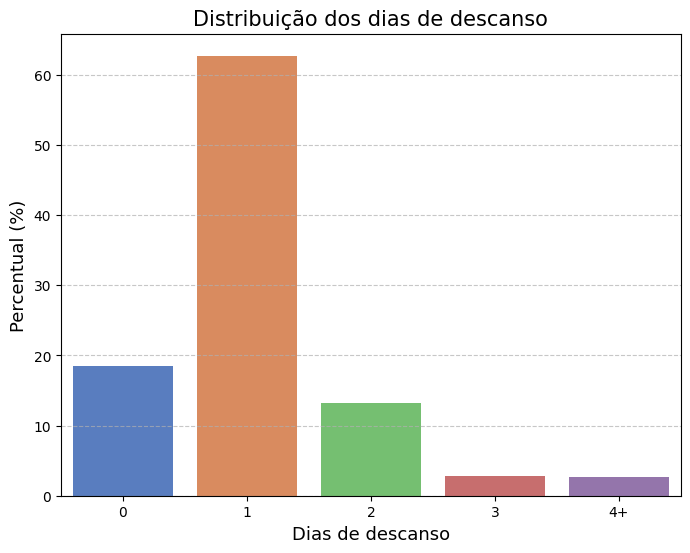

In [54]:
# histograma de dias de descanso
plt.figure(figsize=(8,6))
sns.countplot(x='REST_DAYS', data=df, stat='percent', palette='muted')
plt.title('Distribuição dos dias de descanso', loc='center', fontsize=15)
plt.xlabel("Dias de descanso", fontsize=13, loc='center')
plt.ylabel("Percentual (%)", fontsize=13, loc='center')
plt.grid(visible=True, alpha=0.7, ls='--', axis='y')
plt.savefig('grafico_descanso.jpg') 
plt.show()

C:\Users\6laur\AppData\Local\Temp\ipykernel_27480\3268121722.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='REST_DAYS', y='WL', data=df, palette='muted', errorbar=None)


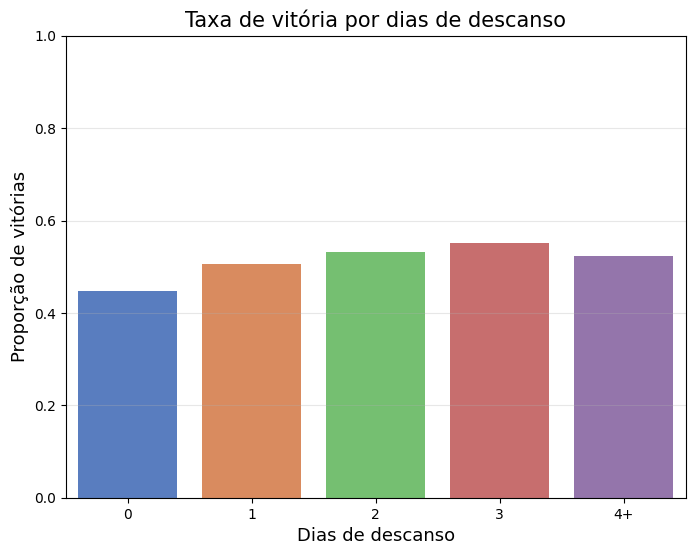

In [55]:
plt.figure(figsize=(8,6))
sns.barplot(x='REST_DAYS', y='WL', data=df, palette='muted', errorbar=None)
plt.title('Taxa de vitória por dias de descanso', fontsize=15, loc='center')
plt.xlabel('Dias de descanso', fontsize=13, loc='center')
plt.ylabel('Proporção de vitórias', fontsize=13, loc='center')
plt.ylim(0,1)
plt.grid(axis='y', alpha=0.3)
plt.savefig('vitoria_por_descanso.jpg')
plt.show()

C:\Users\6laur\AppData\Local\Temp\ipykernel_27480\1374474999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='REST_DAYS', y='PLUS_MINUS', data=df, palette='muted')


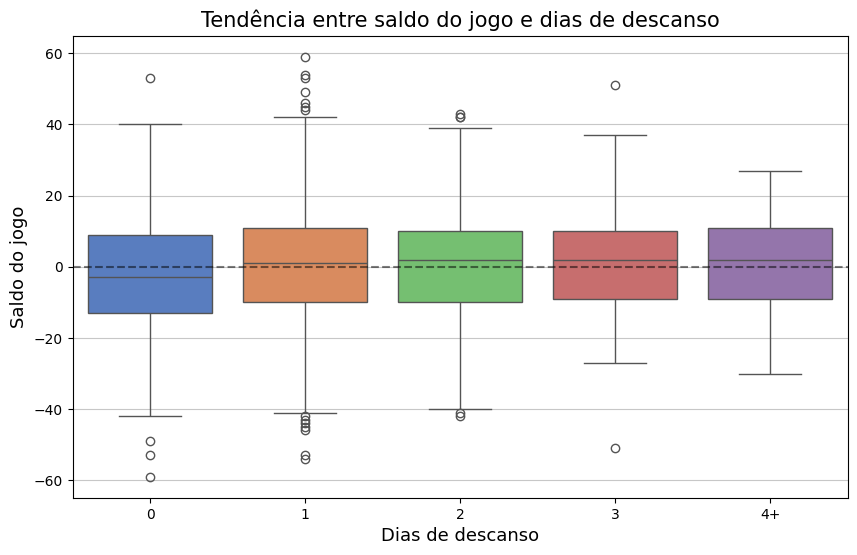

In [64]:
plt.figure(figsize=(10,6))
sns.boxplot(x='REST_DAYS', y='PLUS_MINUS', data=df, palette='muted')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Tendência entre saldo do jogo e dias de descanso', fontsize=15, loc='center')
plt.xlabel('Dias de descanso', fontsize=13, loc='center')
plt.ylabel('Saldo do jogo', fontsize=13, loc='center')
plt.grid(axis='y', alpha=0.7)
plt.savefig('tendencia_saldo_por_descanso.jpg')
plt.show()

C:\Users\6laur\AppData\Local\Temp\ipykernel_27480\364561192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df.HOME_AWAY.map({0:'Fora de casa', 1: 'Casa'}), y='PLUS_MINUS', data=df, palette='muted')


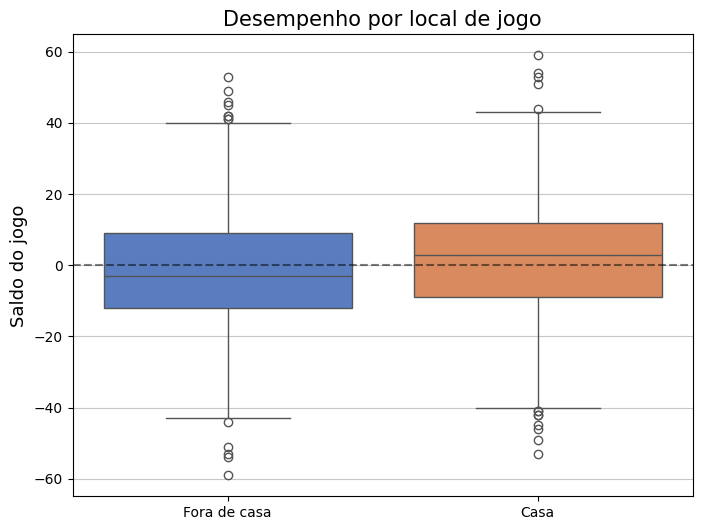

In [63]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df.HOME_AWAY.map({0:'Fora de casa', 1: 'Casa'}), y='PLUS_MINUS', data=df, palette='muted')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Desempenho por local de jogo', fontsize=15, loc='center')
plt.xlabel('')
plt.ylabel('Saldo do jogo', fontsize=13, loc='center')
plt.grid(axis='y', alpha=0.7)
plt.savefig('desempenho_por_local_jogo.jpg')
plt.show()